In [1]:
# Check python version
#@title Imports (RUN ME!) { display-mode: "form" }
import sys,os
sys.version

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, BatchNormalization, Activation
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras import regularizers
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


In [2]:
import sys
import skimage
import sklearn
import keras
print('Python       :', sys.version.split('\n')[0])
print('Numpy        :', np.__version__)
print('Skimage      :', skimage.__version__)
print('Scikit-learn :', sklearn.__version__)
print('Keras        :', keras.__version__)
print('Tensorflow   :', tf.__version__)

Python       : 3.11.13 (main, Jun  5 2025, 08:21:08) [Clang 14.0.6 ]
Numpy        : 2.0.2
Skimage      : 0.26.0
Scikit-learn : 1.6.1
Keras        : 3.12.1
Tensorflow   : 2.21.0


In [3]:
root_dir = "/Users/triscillar/Documents/Professional development/Journal Submissions/data MDPI/Wildlife Fences Dataset/Aerial_Images/Classification/Images/"
os.listdir(root_dir)

['.DS_Store', 'double_fence', 'single_fence']

In [4]:
path = os.path.join(root_dir)

# EDA

In [5]:
#view files
for file, folder in [('labels.csv','fence'),('labels.csv','fences')]:
    print(file)
    print(folder)


labels.csv
fence
labels.csv
fences


In [6]:
# view files
for f in os.listdir(path):
    print(f)

.DS_Store
double_fence
single_fence


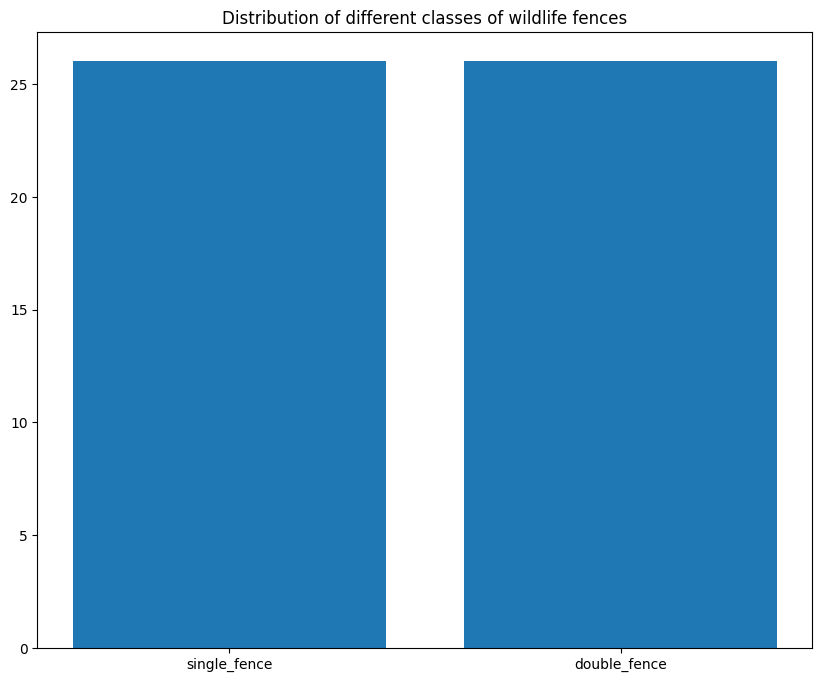

In [7]:
image_folder = ['single_fence', 'double_fence']
nimgs = {}
for i in image_folder:
    nimages = len(os.listdir(path+i+'/'))
    nimgs[i]=nimages
plt.figure(figsize=(10, 8))
plt.bar(range(len(nimgs)), list(nimgs.values()), align='center')
plt.xticks(range(len(nimgs)), list(nimgs.keys()))
plt.title('Distribution of different classes of wildlife fences')
plt.show()

In [8]:
for i in ['single_fence', 'double_fence']:
    print('Valid {} images are: '.format(i)+str(len(os.listdir(path+i+'/'))))

Valid single_fence images are: 26
Valid double_fence images are: 26


## Generate Dataset

In [9]:
img_width, img_height = 512, 512 #256, 256
image_size = (img_width, img_height)
batch_size = 12

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    path,
    validation_split=0.2,
    subset="training",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size
    #labels='inferred',
    #label_mode = 'categorical'
    
    
)
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    path,
    validation_split=0.2,
    subset="validation",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size
    #labels='inferred',
    #label_mode = 'categorical'
)

Found 52 files belonging to 2 classes.
Using 42 files for training.
Found 52 files belonging to 2 classes.
Using 10 files for validation.


In [10]:
class_names = train_ds.class_names
print(class_names)

['double_fence', 'single_fence']


In [11]:
class_names = val_ds.class_names
print(class_names)

['double_fence', 'single_fence']


### Visualize the data
Here are the first 9 images in the training dataset. As you can see, we have label single_fence and double_fence

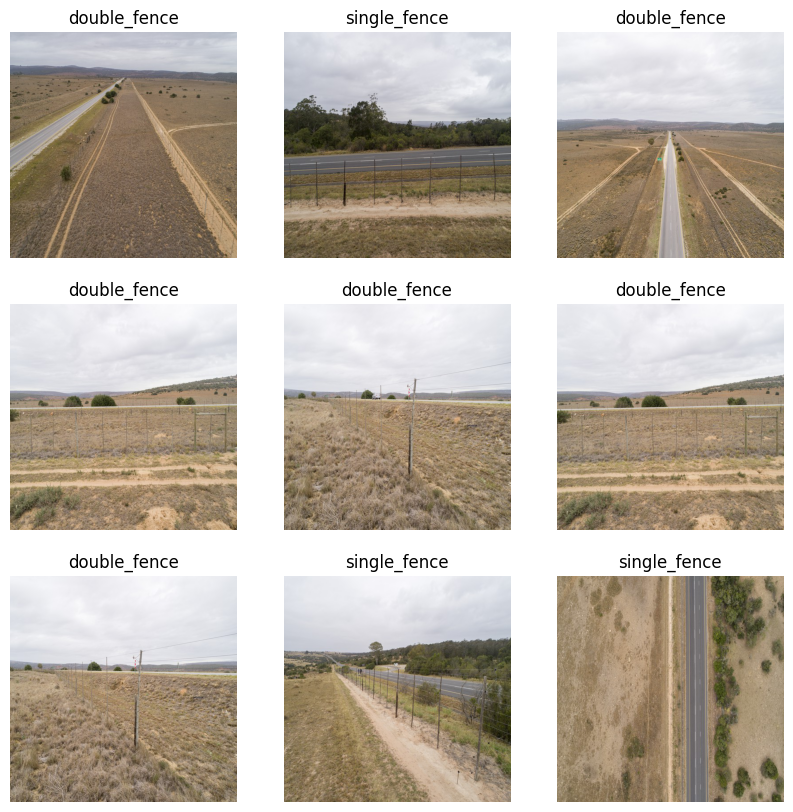

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

The `image_batch` is a tensor of the shape `(12, 256, 256, 3)`. This is a batch of 32 images of shape `256x256x3` (the last dimension refers to color channels RGB). The `label_batch` is a tensor of the shape `(12,)`, these are corresponding labels to the 12 images. 

You can call `.numpy()` on the `image_batch` and `labels_batch` tensors to convert them to a `numpy.ndarray`.


In [13]:
for image_batch, labels_batch in train_ds:
    print(image_batch.shape)
    print(labels_batch.shape)
    break

(12, 512, 512, 3)
(12,)


### Using image data augmentation
Very helpful when you don't have a large image dataset, it's a good practice to artificially introduce sample diversity by applying random yet realistic transformations to the training images, such as random horizontal flipping or small random rotations. This helps expose the model to different aspects of the training data while slowing down overfitting.

In [14]:
# Updated import path for newer TensorFlow versions
data_augmentation = tf.keras.Sequential([
  tf.keras.layers.RandomFlip("horizontal_and_vertical", input_shape=(img_height, img_width, 3)),  # Moved from experimental to main layers
  tf.keras.layers.RandomRotation(0.2),  # Updated path
  tf.keras.layers.RandomZoom(0.1),  # Updated path
])

/opt/anaconda3/lib/python3.11/site-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


visualizing augmented samples, by applying data_augmentation repeatedly to the first 9 images in the dataset

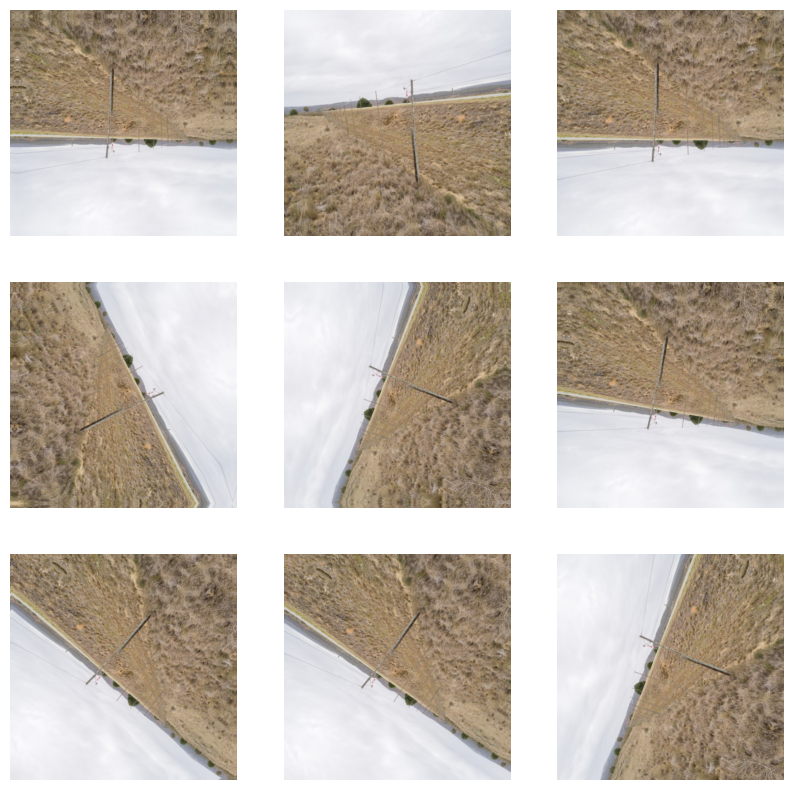

In [15]:
plt.figure(figsize=(10, 10))
for images, _ in train_ds.take(1):
    for i in range(9):
        augmented_images = data_augmentation(images)
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(augmented_images[0].numpy().astype("uint8"))
        plt.axis("off")

### Standardizing the data
The image dataset is in a standard size (256x256) since they are represented as as contiguous float32 batches. And, their RGB channel values are in the [0, 255] range which not ideal for a NN. Standadizing means aiming to make the input values small. Here, we will standardize values to be in the [0, 1] by using a Rescaling layer at the start of our model.




In [16]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

In [17]:
normalized_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
image_batch, labels_batch = next(iter(normalized_ds))
first_image = image_batch[0]
# Notice the pixels values are now in `[0,1]`.
print(np.min(first_image), np.max(first_image))

0.0 1.0


### Configure the dataset for performance

Let's make sure to use buffered prefetching, so you can yield data from disk without having I/O become blocking. These are two important methods you should use when loading data.

`.cache()` keeps the images in memory after they're loaded off disk during the first epoch. This will ensure the dataset does not become a bottleneck while training your model. If your dataset is too large to fit into memory, you can also use this method to create a performant on-disk cache.

`.prefetch()` overlaps data preprocessing and model execution while training. 
Refer to  [data performance guide](https://www.tensorflow.org/guide/data_performance#prefetching).

In [18]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

# Build Model

The standard model consists of three convolution blocks with a max pool layer in each of them. There's a fully connected layer with 15 units on top of it that is activated by a relu activation function. 



In [19]:
num_classes = 2

model = Sequential([
  data_augmentation ,
  tf.keras.layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)),
  tf.keras.layers.Conv2D(10, 3, padding='same'),
  tf.keras.layers.BatchNormalization(),
  tf.keras.layers.Activation('relu'),
  tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
  tf.keras.layers.Dropout(0.1),
  tf.keras.layers.Flatten(),
  tf.keras.layers.Dense(15),
  tf.keras.layers.BatchNormalization(),
  tf.keras.layers.Activation('relu'),
  #layers.Dropout(0.1),
  tf.keras.layers.Dense(num_classes)
])


# Train Model

In [20]:
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(monitor='loss',patience=20, restore_best_weights=True)

In [21]:
epochs = 500
model.compile(
    #optimizer = keras.optimizers.RMSprop(learning_rate=lr_schedule),
    optimizer=tf.keras.optimizers.Adam(1e-3),#),# , 10e-6
    #optimizer = keras.optimizers.RMSprop(learning_rate=lr_schedule),
    #optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule),
     loss="sparse_categorical_crossentropy",#categorical_crossentropy",#loss='sparse_categorical_crossentropy',
         metrics=['accuracy'],
)

In [22]:
history=model.fit(train_ds, epochs=epochs, callbacks = [early_stop], validation_data=val_ds)


Epoch 1/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 416ms/step - accuracy: 0.4286 - loss: 4.1427 - val_accuracy: 0.5000 - val_loss: 8.0590
Epoch 2/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 386ms/step - accuracy: 0.4524 - loss: 3.6476 - val_accuracy: 0.5000 - val_loss: 8.0590
Epoch 3/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 301ms/step - accuracy: 0.5238 - loss: 3.0052 - val_accuracy: 0.5000 - val_loss: 8.0590
Epoch 4/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 313ms/step - accuracy: 0.6190 - loss: 2.3683 - val_accuracy: 0.5000 - val_loss: 8.0590
Epoch 5/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 331ms/step - accuracy: 0.5714 - loss: 2.5949 - val_accuracy: 0.5000 - val_loss: 8.0590
Epoch 6/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 324ms/step - accuracy: 0.5476 - loss: 1.8696 - val_accuracy: 0.5000 - val_loss: 8.0590
Epoch 7/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 307ms/step - accuracy: 0.5952 - loss: 2.3384 - val_accuracy: 0.5000 - val_loss: 8.0590
Epoch 8/500
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 304ms/step - accuracy: 0.7143 - loss: 2.6982 - val_accuracy: 0.5000 - v

In [23]:
pwd

'/Users/triscillar/Documents/Professional development/Journal Submissions/data MDPI/Baseline  notebooks'

In [24]:
# Save the entire model as a `.keras` zip archive.
model.save('my_model_classify.keras')

### visualising the results

In [25]:
# Loss Curves
def plot_curves(history):
    plt.figure(figsize=[14,10])
    plt.subplot(211)
    plt.plot(history.history['loss'],'r',linewidth=3.0)
    plt.plot(history.history['val_loss'],'b',linewidth=3.0)
    plt.legend(['Training loss', 'Validation Loss'],fontsize=18)
    plt.xlabel('Epochs ',fontsize=16)
    plt.ylabel('Loss',fontsize=16)
    plt.title('Loss Curves for Aerial Images',fontsize=16)
    
    # Accuracy Curves
    plt.figure(figsize=[14,10])
    plt.subplot(212)
    plt.plot(history.history['accuracy'],'r',linewidth=3.0)
    plt.plot(history.history['val_accuracy'],'b',linewidth=3.0)
    plt.legend(['Training Accuracy', 'Validation Accuracy'],fontsize=18)
    plt.xlabel('Epochs ',fontsize=16)
    plt.ylabel('Accuracy',fontsize=16)
    plt.title('Accuracy Curves for Aerial Images',fontsize=16)

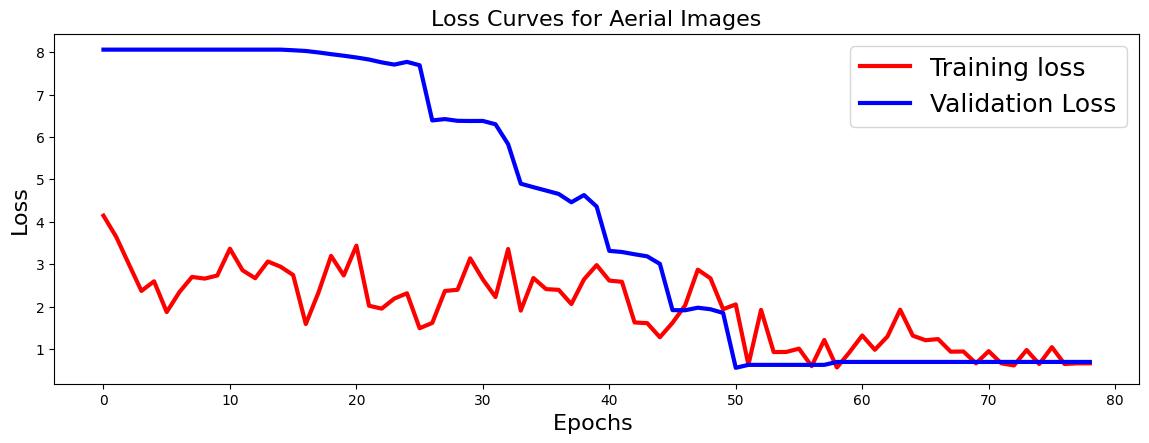

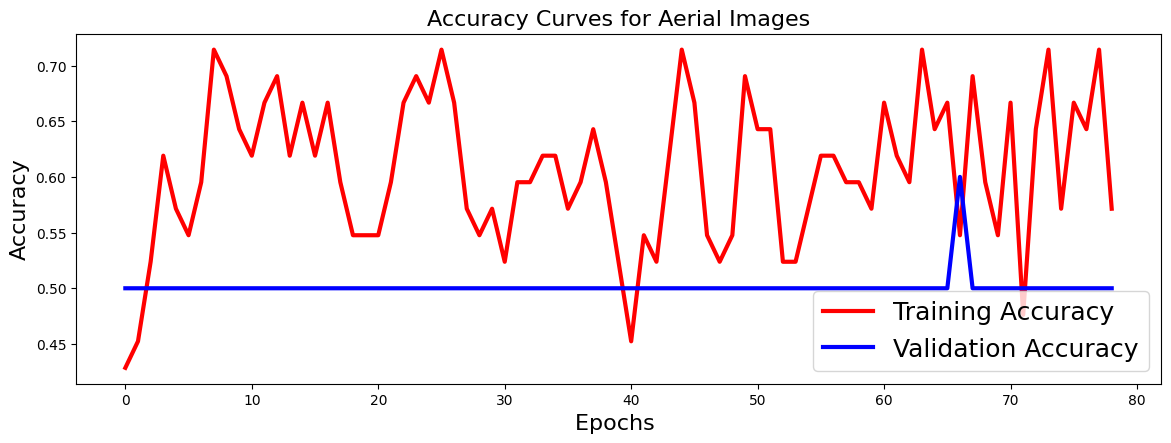

In [26]:
plot_curves(history)

# Make predictions 
With the model trained, you can use it to make predictions about some images. The model's linear outputs, logits. Attach a softmax layer to convert the logits to probabilities, which are easier to interpret. 

In [27]:

# Load the saved model
new_model = tf.keras.models.load_model('my_model_classify.keras')

In [28]:
probability_model = tf.keras.Sequential([new_model, 
                                         tf.keras.layers.Softmax()])


In [29]:
predictions = probability_model.predict(val_ds)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step


Here, the model has predicted the label for each image in the testing set. Let's take a look at the first prediction:

In [30]:
predictions[0]


array([0.55362916, 0.44637078], dtype=float32)

A prediction is an array of 2 numbers. They represent the model's "confidence" that the image corresponds to each of the 2 different images of fences. You can see which label has the highest confidence value:

In [31]:
np.argmax(predictions[0])


np.int64(0)

So, the model is most confident that this image is an double fence, or class_names[1]. Examining the val label shows that this classification is correct:

In [32]:
# get the labels 
predictions = np.array([])
labels =  np.array([])

for x, y in val_ds:
    predictions = np.concatenate([predictions, np.argmax(new_model.predict(x), axis=-1)])
    labels = np.concatenate([labels, y.numpy()])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step


In [33]:
predictions

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [34]:
len(predictions)

10

In [35]:
labels.shape

(10,)

In [36]:
len(labels)

10

In [37]:
m = tf.keras.metrics.Accuracy()
m(labels, predictions).numpy()


np.float32(0.5)

In [38]:
#labels that were not predicted
set(labels) - set(predictions)

{np.float64(1.0)}

In [39]:
# this shows that you are not interested in the labels that were not predicted
# we are interested in the labels that were predicted at least once
from sklearn.metrics import f1_score
f1_score(labels, predictions,  average='weighted', labels=np.unique(predictions))
#0.91076923076923078

0.6666666666666666

In [40]:
print('Classification Report')
target_names = ['single_fence', 'double_fence']
print(classification_report(labels, predictions, target_names=target_names, labels=np.unique(predictions)))

Classification Report
              precision    recall  f1-score   support

single_fence       0.50      1.00      0.67         5

   micro avg       0.50      1.00      0.67         5
   macro avg       0.50      1.00      0.67         5
weighted avg       0.50      1.00      0.67         5



/opt/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:2687: UserWarning: labels size, 1, does not match size of target_names, 2
  warnings.warn(


In [41]:
# First, ensure both arrays have the same length by checking their shapes
print(f"Labels shape: {labels.shape}")
print(f"Predictions shape: {predictions.shape}")

# Make sure both arrays have the same number of samples
# Option 1: If you need to truncate to the smaller size
min_length = min(len(labels), len(predictions))
labels_aligned = labels[:min_length]
predictions_aligned = predictions[:min_length]

# Option 2: Or ensure your data preprocessing keeps them aligned
# (This is the preferred approach - fix the root cause)

# Generate the classification report with aligned data
print(classification_report(labels_aligned, predictions_aligned, 
                          target_names=target_names, 
                          labels=np.unique(predictions_aligned)))

Labels shape: (10,)
Predictions shape: (10,)
              precision    recall  f1-score   support

single_fence       0.50      1.00      0.67         5

   micro avg       0.50      1.00      0.67         5
   macro avg       0.50      1.00      0.67         5
weighted avg       0.50      1.00      0.67         5



/opt/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:2687: UserWarning: labels size, 1, does not match size of target_names, 2
  warnings.warn(


In [42]:
labels_aligned.shape

(10,)

**Test the Model Performance**

### Single Image

In [43]:
img = keras.preprocessing.image.load_img(
    path+"double_fence/Rhodes-University-Location-2-Image-Data%20(112).png", target_size=image_size
)


In [44]:
img_array = keras.preprocessing.image.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)  # Create batch axis


In [45]:
predictions = probability_model.predict(img_array)
score = predictions[0]


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step


In [46]:
print(
    "This image most likely belongs to {} with a {:.2f} percent confidence."
    .format(class_names[np.argmax(score)], 100 * np.max(score))
)


This image most likely belongs to double_fence with a 87.99 percent confidence.


In [47]:
print(
    "This image most likely does not belong to {} with a {:.2f} percent confidence."
    .format(class_names[np.argmin(score)], 100 * np.min(score))
)

This image most likely does not belong to single_fence with a 12.01 percent confidence.


#### Let us see how our model performs on the testing data. Remember, the testing data is the data the model hasn’t seen during the training process.

In [48]:

# Getting test accuracy and loss
test_loss, test_acc = new_model.evaluate(val_ds)
print('Test loss: {} Test Acc: {}'.format(test_loss, test_acc))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step - accuracy: 0.5000 - loss: 0.6931
Test loss: 0.6931471824645996 Test Acc: 0.5


#### We get a test loss of approximately 0.69 and a test accuracy of approximately 0.5